In [2]:
import numpy as np


def read_latency_data(file, ignore):
    data = {"end_to_end": [], "service": []}
    with open(file, "r") as file:
        for line in file.readlines():
            span, latency = line.strip().split(",")
            assert span in data.keys()
            data[span].append(int(latency))
    for span in data.keys():
        n_ignore = int(len(data[span]) * ignore)
        data[span] = data[span][n_ignore:]
    return data 


def get_pctl(data, pctl):
    data = np.sort(data)
    tail = np.percentile(data, pctl).astype(int)
    return tail

In [3]:
rps_values = list(range(200, 2001, 200))
e2e_data = {
    "rps": [],
    "fcfs": [],
    "masa": [],
}
svc_data = {
    "rps": [],
    "fcfs": [],
    "masa": [],
}

pctl = 99
for rps in rps_values:
    e2e_data["rps"].append(rps)
    svc_data["rps"].append(rps)

    file = f"r{rps}-fcfs.csv"
    data = read_latency_data(file, ignore=0.01)
    e2e_data["fcfs"].append(get_pctl(data["end_to_end"], pctl))
    svc_data["fcfs"].append(get_pctl(data["service"], pctl))

    file = f"r{rps}-masa.csv"
    data = read_latency_data(file, ignore=0.01)
    e2e_data["masa"].append(get_pctl(data["end_to_end"], pctl))
    svc_data["masa"].append(get_pctl(data["service"], pctl))

print(e2e_data)
print()
print(svc_data)

{'rps': [200, 400, 600, 800, 1000, 1200, 1400, 1600, 1800, 2000], 'fcfs': [43615, 48969, 55667, 66537, 80489, 97290, 135503, 196984, 453771, 1586227], 'masa': [43495, 47488, 52553, 60748, 71380, 83588, 114307, 163802, 357305, 1209407]}

{'rps': [200, 400, 600, 800, 1000, 1200, 1400, 1600, 1800, 2000], 'fcfs': [13685, 14400, 16523, 19739, 23192, 30660, 43523, 64549, 151057, 463374], 'masa': [13685, 14378, 16304, 20966, 26708, 36030, 52248, 77630, 173686, 660502]}


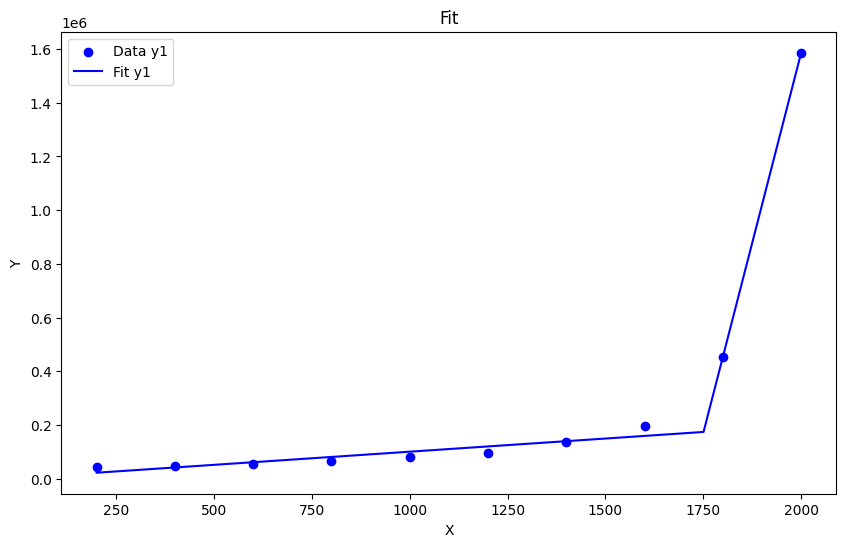

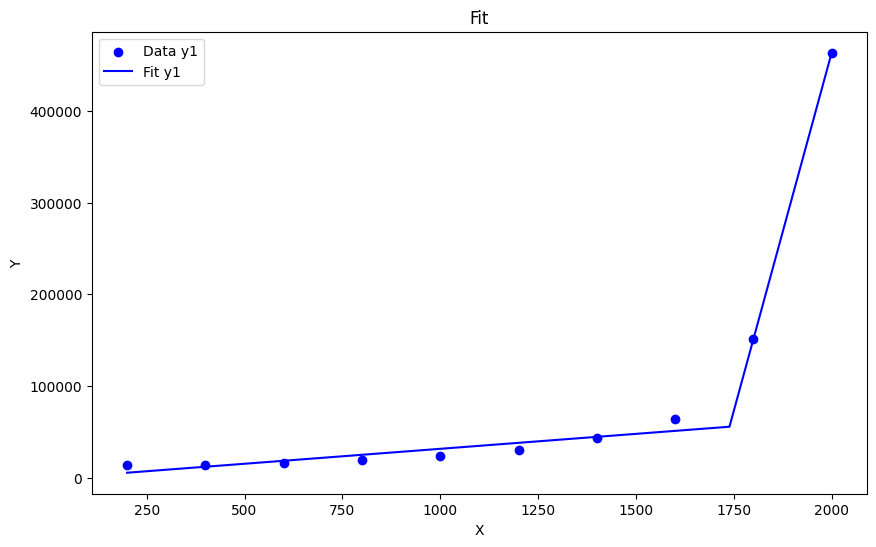

100000 996 16667 544 

200000 1755 33333 1055 

300000 1773 50000 1566 

400000 1791 66667 1746 

500000 1808 83333 1757 

600000 1826 100000 1767 

700000 1843 116667 1778 

800000 1861 133333 1789 

900000 1879 150000 1799 

1000000 1896 166667 1810 



/tmp/ipykernel_820991/1740158651.py:34: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  return fsolve(lambda x: p(x) - target, 1000)


In [8]:
import numpy as np
import matplotlib.pyplot as plt
import pwlf
from scipy.optimize import fsolve


def plot(data):
    n_points = len(data["rps"])
    x = np.array(data["rps"][:n_points])
    y1 = np.array(data["fcfs"][:n_points])
    # y2 = np.array(data["masa"][:n_points])

    # Plotting
    plt.figure(figsize=(10, 6))
    plt.scatter(x, y1, color="blue", label="Data y1")
    # plt.scatter(x, y2, color="green", label="Data y2")

    fit = pwlf.PiecewiseLinFit(x, y1)
    fit.fit(2)
    x_hat = np.linspace(min(x), max(x), num=10000)
    y_hat = fit.predict(x_hat)
    plt.plot(x_hat, y_hat, color="blue", label="Fit y1")

    plt.title("Fit")
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.legend()
    plt.show()

    return fit


def solve(p, target):
    return fsolve(lambda x: p(x) - target, 1000)


e2e_fit = plot(e2e_data)
svc_fit = plot(svc_data)

slos = [i * 1e5 for i in range(1, 11)]
for slo in slos:
    print(
        round(slo),
        round(solve(e2e_fit.predict, slo)[0]),
        round(slo / 6),
        round(solve(svc_fit.predict, slo / 6)[0]),
        "\n",
    )